# Silver Label Generation Pipeline

## a. TF-IDF

## b. SVD

## c. BERT

## d. Review of a, b & c

## e. Embedding Table

## f. Silver Label
### I. a, b & c
### II. Hybrid Labels

## g. Review

In [1]:
# Relevant imports
from pathlib import Path
from collections import defaultdict, Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD
from transformers import AutoTokenizer, AutoModel
import pickle
import numpy as np
import re
import random
import torch
import scipy.sparse as sp
import scipy.sparse
import matplotlib.pyplot as plt

# Random
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)
device = "cuda" if torch.cuda.is_available() else "cpu"

# Setup initial filepaths
ROOT = Path(".")

TRAIN_CORPUS_PATH = ROOT / "Amazon_products" / "train" / "train_corpus.txt"
CLASSES_PATH      = ROOT / "Amazon_products" / "classes.txt"
HIERARCHY_PATH    = ROOT / "Amazon_products" / "class_hierarchy.txt"
KEYWORDS_PATH     = ROOT / "Amazon_products" / "class_related_keywords.txt"

REPRESENTATION_PATH = ROOT / "representations"
REPRESENTATION_PATH.mkdir(exist_ok=True)
# Paths for saved embeddings
TFIDF_PATH = REPRESENTATION_PATH / "tfidf"
TFIDF_PATH.mkdir(exist_ok=True)

SVD_PATH = REPRESENTATION_PATH / "svd_cooccurrence"
SVD_PATH.mkdir(parents=True, exist_ok=True)

BERT_PATH = REPRESENTATION_PATH / "transformer"
BERT_PATH.mkdir(exist_ok=True)

SILVER_PATH = ROOT / "silver_labels"
SILVER_PATH.mkdir(exist_ok=True)
HYBRID_PATH = SILVER_PATH


In [2]:
# Preprocessing
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Load corpus
def load_corpus(path):
    with open(path, "r", encoding="utf8") as f:
        return {i: preprocess_text(line.strip()) for i, line in enumerate(f)}

def load_class_keywords(path):
    class_dict = {}
    with open(path, "r", encoding="utf8") as f:
        for line in f:
            if ":" not in line:
                continue
            cls_raw, kws_raw = line.split(":", 1)
            cls = preprocess_text(cls_raw)
            kws = [preprocess_text(k) for k in kws_raw.split(",") if k.strip()]
            class_dict[cls] = kws
    return class_dict

# Load files
train_corpus = load_corpus(TRAIN_CORPUS_PATH)
class_keywords = load_class_keywords(KEYWORDS_PATH)
class_names = list(class_keywords.keys())

train_ids, train_texts = list(train_corpus.keys()), list(train_corpus.values())
keyword_docs = [" ".join(kws) for kws in class_keywords.values()]
keyword_names = list(class_keywords.keys())

# a. TF-IDF

In [3]:
# TF-IDF vectorization
vectorizer = TfidfVectorizer(max_features=5000)
vectorizer.fit(train_texts + keyword_docs)

train_tfidf = vectorizer.transform(train_texts)
keyword_tfidf = vectorizer.transform(keyword_docs)


# Compute cosine similarity-
similarity_matrix_tfidf = cosine_similarity(train_tfidf, keyword_tfidf)
# shape: (num_train_docs, num_classes)

# Generate silver labels
k = 3  # top-k classes
confidence_threshold = 0.5

silver_labels_tfidf = []

for i, sims in enumerate(similarity_matrix_tfidf):
    top_indices = sims.argsort()[::-1][:k]
    top_classes = [(keyword_names[idx], sims[idx]) for idx in top_indices if sims[idx] >= confidence_threshold]

    if not top_classes:
        silver_labels_tfidf.append((train_ids[i], []))
    else:
        silver_labels_tfidf.append((train_ids[i], top_classes))

# Inspect first 10 entries
for entry in silver_labels_tfidf[:10]:
    pid, top_classes = entry
    print(f"Product {pid}: {top_classes}")

# Save vectorizer and TF-IDF matrices
with open(TFIDF_PATH / "vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

scipy.sparse.save_npz(TFIDF_PATH / "X_train_tfidf.npz", train_tfidf)
scipy.sparse.save_npz(TFIDF_PATH / "X_keywords_tfidf.npz", keyword_tfidf)

print("[Done] Saved TF-IDF matrices and vectorizer.")
print("[Done] Generated silver labels for", len(silver_labels_tfidf), "products.")

Product 0: []
Product 1: []
Product 2: []
Product 3: []
Product 4: []
Product 5: []
Product 6: []
Product 7: []
Product 8: []
Product 9: []
[Done] Saved TF-IDF matrices and vectorizer.
[Done] Generated silver labels for 29487 products.


# b. SVD

In [4]:
TOP_VOCAB = 20000
WINDOW_SIZE = 4
SVD_DIM = 300
MIN_FREQ = 2
K = 3
CONF_THRESH = 0.5

token_counter = Counter()
def tokenize(text):
    return text.split() if text else []

for txt in train_texts:
    token_counter.update(tokenize(txt))
for txt in keyword_docs:
    token_counter.update(tokenize(txt))

filtered = [(tok, cnt) for tok, cnt in token_counter.items() if cnt >= MIN_FREQ]
filtered.sort(key=lambda x: x[1], reverse=True)
vocab_tokens = [tok for tok, _ in filtered[:TOP_VOCAB]]
vocab_set = set(vocab_tokens)
vocab = {tok: i for i, tok in enumerate(vocab_tokens)}
V = len(vocab)

rows = []
cols = []
data = []

cooc = defaultdict(Counter)

for idx, txt in enumerate(train_texts):
    toks = [t for t in tokenize(txt) if t in vocab_set]
    L = len(toks)
    for i, tok in enumerate(toks):
        wi = vocab[tok]
        start = max(0, i - WINDOW_SIZE)
        end = min(L, i + WINDOW_SIZE + 1)
        for j in range(start, end):
            if j == i:
                continue
            tj = toks[j]
            wj = vocab[tj]
            cooc[wi][wj] += 1

for i, neigh in cooc.items():
    for j, cnt in neigh.items():
        rows.append(i)
        cols.append(j)
        data.append(cnt)

# Build sparse matrix (V x V)
C = sp.coo_matrix((data, (rows, cols)), shape=(V, V), dtype=np.float32)
C = C.tocsr()

# Apply Truncated SVD
svd = TruncatedSVD(n_components=SVD_DIM, n_iter=10, random_state=42)
# TruncatedSVD accepts sparse input
word_embeddings = svd.fit_transform(C)  # shape: (V, d)

# Optionally normalize embeddings (helps cosine similarity)
def l2_normalize_rows(mat):
    norms = np.linalg.norm(mat, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    return mat / norms

word_embeddings = l2_normalize_rows(word_embeddings)

with open(SVD_PATH / "svd_model.pkl", "wb") as f:
    pickle.dump(svd, f)
np.save(SVD_PATH / "word_embeddings.npy", word_embeddings)
with open(SVD_PATH / "vocab.pkl", "wb") as f:
    pickle.dump(vocab, f)

def doc_to_embedding(text, word_embeddings, vocab, use_tf_weights=True):
    toks = [t for t in tokenize(text) if t in vocab]
    if not toks:
        return np.zeros((word_embeddings.shape[1],), dtype=np.float32)
    counts = Counter(toks)
    if use_tf_weights:
        total = sum(counts.values())
        emb = np.zeros((word_embeddings.shape[1],), dtype=np.float32)
        for tok, cnt in counts.items():
            emb += (cnt / total) * word_embeddings[vocab[tok]]
        return emb
    else:
        vecs = [word_embeddings[vocab[t]] for t in toks]
        return np.mean(vecs, axis=0)


train_dense = np.zeros((len(train_texts), SVD_DIM), dtype=np.float32)
for i, txt in enumerate(train_texts):
    train_dense[i] = doc_to_embedding(txt, word_embeddings, vocab, use_tf_weights=True)

keyword_dense = np.zeros((len(keyword_docs), SVD_DIM), dtype=np.float32)
for i, txt in enumerate(keyword_docs):
    keyword_dense[i] = doc_to_embedding(txt, word_embeddings, vocab, use_tf_weights=True)


train_dense = l2_normalize_rows(train_dense)
keyword_dense = l2_normalize_rows(keyword_dense)

# Compute cosine similarities and generate silver labels
similarity_matrix_svd = cosine_similarity(train_dense, keyword_dense)  # shape (num_train, num_classes)

silver_labels_svd = []
for i, sims in enumerate(similarity_matrix_svd):
    top_indices = sims.argsort()[::-1][:K]
    top_classes = [(keyword_names[idx], float(sims[idx])) for idx in top_indices if sims[idx] >= CONF_THRESH]
    if not top_classes:
        silver_labels_svd.append((train_ids[i], []))
    else:
        silver_labels_svd.append((train_ids[i], top_classes))

# Inspect first 10
for entry in silver_labels_svd[:10]:
    pid, top_classes = entry
    print(f"Product {pid}: {top_classes}")

scipy.sparse.save_npz(SVD_PATH / "X_train_svd.npz", sp.csr_matrix(train_dense))
scipy.sparse.save_npz(SVD_PATH / "X_keywords_svd.npz", sp.csr_matrix(keyword_dense))

with open(SVD_PATH / "silver_labels_svd.pkl", "wb") as f:
    pickle.dump(silver_labels_svd, f)

print("[Done] Saved train/keyword embeddings and silver labels. Generated silver labels for", len(silver_labels_svd), "products.")

Product 0: [('health monitors', 0.9758671522140503), ('basic life skills toys', 0.9664862155914307), ('eye care', 0.9634793996810913)]
Product 1: [('laundry', 0.97559654712677), ('bubble bath', 0.9728456139564514), ('aquarium d cor', 0.9726720452308655)]
Product 2: [('eye care', 0.9669040441513062), ('personal care', 0.9651252031326294), ('deodorants antiperspirants', 0.9641223549842834)]
Product 3: [('hair color', 0.9672929048538208), ('personal care', 0.9631855487823486), ('shampoo', 0.9555330872535706)]
Product 4: [('safer sex', 0.9643348455429077), ('eye care', 0.9629898071289062), ('monitors', 0.9628899693489075)]
Product 5: [('eye care', 0.9691740870475769), ('personal care', 0.9687617421150208), ('safer sex', 0.9669018983840942)]
Product 6: [('sand water tables', 0.9653833508491516), ('baby child care', 0.9644197821617126), ('basic life skills toys', 0.9640074372291565)]
Product 7: [('basic life skills toys', 0.9760237336158752), ('baby gyms playmats', 0.9716888070106506), ('lau

# c. BERT

In [5]:
model_name = "sentence-transformers/all-mpnet-base-v2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to(device)

def embed_texts(texts, batch_size=32):
    embeddings = []
    total_batches = (len(texts) + batch_size - 1) // batch_size
    for i in range(0, len(texts), batch_size):
        batch_num = i // batch_size + 1
        batch_texts = texts[i:i+batch_size]
        encoded = tokenizer(batch_texts, padding=True, truncation=True, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = model(**encoded)
            batch_embeddings = outputs.last_hidden_state.mean(dim=1)
            embeddings.append(batch_embeddings.cpu().numpy())
    return np.vstack(embeddings)

train_embeddings = embed_texts(train_texts, batch_size=64)
keyword_embeddings = embed_texts(keyword_docs, batch_size=64)

# Compute cosine similarity
similarity_matrix_bert = cosine_similarity(train_embeddings, keyword_embeddings)

k = 3
confidence_threshold = 0.5
silver_labels_bert = []

total_products = len(train_ids)
for i, sims in enumerate(similarity_matrix_bert):
    top_indices = sims.argsort()[::-1][:k]
    top_classes = [(keyword_names[idx], sims[idx]) for idx in top_indices if sims[idx] >= confidence_threshold]
    silver_labels_bert.append((train_ids[i], top_classes if top_classes else []))

with open(SILVER_PATH / "silver_labels_bert.pkl", "wb") as f:
    pickle.dump(silver_labels_bert, f)

print("[DONE] Generated SVD/BERT silver labels for", len(silver_labels_bert), "products.")


2025-12-17 13:57:47.625658: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765979867.633822    5757 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765979867.636403    5757 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-17 13:57:47.645121: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


[DONE] Generated SVD/BERT silver labels for 29487 products.


# d. Review of a, b & c

In [6]:
# First simple sanity check 

def show_top_silver_examples(silver_labels, train_texts, min_conf=0.6, top_n=5):
    flattened = []
    for pid, cls_list in silver_labels:
        for cls_name, score in cls_list:
            flattened.append((pid, cls_name, float(score)))

    filtered = [x for x in flattened if x[2] >= min_conf]
    filtered_sorted = sorted(filtered, key=lambda x: x[2], reverse=True)

    print(f"\nShowing top {top_n} examples with confidence >= {min_conf}:\n")
    for pid, cls, score in filtered_sorted[:top_n]:
        print("\n=====================================================")
        print(f"Review ID: {pid}")
        print(f"Confidence: {score:.4f}")
        print(f"Predicted class: {cls}")
        print("\nReview text:")
        print(train_texts[pid])

# For TF-IDF silver labels
show_top_silver_examples(silver_labels_tfidf, train_texts, min_conf=0.6, top_n=5)

# For SVD silver labels
show_top_silver_examples(silver_labels_svd, train_texts, min_conf=0.6, top_n=5)

# For BERT silver labels
show_top_silver_examples(silver_labels_bert, train_texts, min_conf=0.6, top_n=5)


Showing top 5 examples with confidence >= 0.6:


Review ID: 29048
Confidence: 0.8489
Predicted class: kites wind spinners

Review text:
29048 go fly a kite skywinder 30 x500 we love the go fly a kite kite winder it is easy but not too easy to take the fun out of flying a kite a

Review ID: 23556
Confidence: 0.8170
Predicted class: kites wind spinners

Review text:
23556 kite spool 90 lb test assorted colors like any hobby it takes a while to get the hang of using a kite and the kite string can be an issue this kite string was perfect for my kite and winding and unwinding is not hard to do good quality string well packaged and the clip is very good

Review ID: 27577
Confidence: 0.8125
Predicted class: sauces

Review text:
27577 bone suckin sauce sauce s the sauce a good taste sweet with a hint of heat just wished it was a thicker sauce to me it is more of a marinate

Review ID: 5183
Confidence: 0.8075
Predicted class: seafood

Review text:
5183 sushi chef sushi making kit i had always 

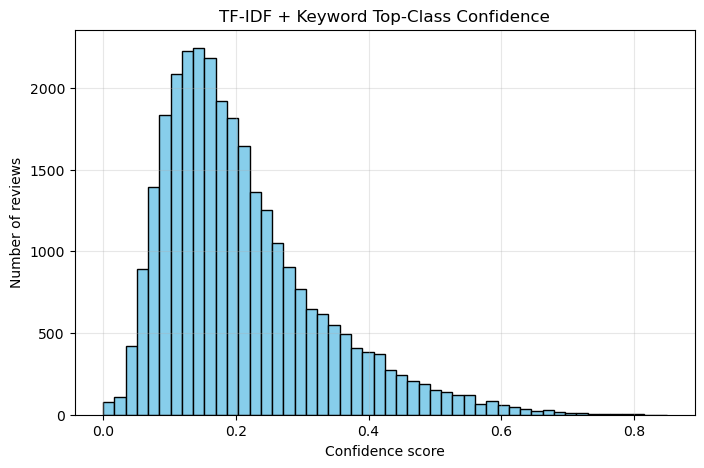

Confidence percentiles: [0.08547794 0.12292037 0.18133797 0.26452902 0.37624693]


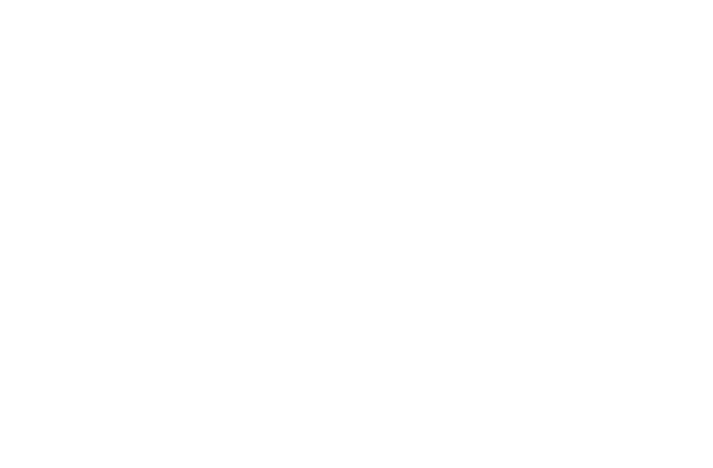

Confidence percentiles: [0.96203716 0.96581051 0.96922791 0.97234675 0.97505002]


'\n# BERT\nmax_conf_bert = plot_top_confidence_distribution(\n    similarity_matrix_bert, \n    title="BERT + Keyword Top-Class Confidence"\n)\n'

In [7]:
def plot_top_confidence_distribution(similarity_matrix, title="Top-Class Confidence Distribution", bins=50, percentiles=[10,25,50,75,90]):
    if hasattr(similarity_matrix, "toarray"):
        sim_dense = similarity_matrix.toarray()
    else:
        sim_dense = similarity_matrix

    max_conf_per_review = sim_dense.max(axis=1)

    plt.figure(figsize=(8,5))
    plt.hist(max_conf_per_review, bins=bins, color='skyblue', edgecolor='black')
    plt.title(title)
    plt.xlabel("Confidence score")
    plt.ylabel("Number of reviews")
    plt.grid(alpha=0.3)
    plt.show()

    print("Confidence percentiles:", np.percentile(max_conf_per_review, percentiles))
    return max_conf_per_review

# TF-IDF
max_conf_tfidf = plot_top_confidence_distribution(
    similarity_matrix_tfidf, 
    title="TF-IDF + Keyword Top-Class Confidence"
)

# SVD
max_conf_svd = plot_top_confidence_distribution(
    similarity_matrix_svd, 
    title="SVD + Keyword Top-Class Confidence"
)
"""
# BERT
max_conf_bert = plot_top_confidence_distribution(
    similarity_matrix_bert, 
    title="BERT + Keyword Top-Class Confidence"
)
"""


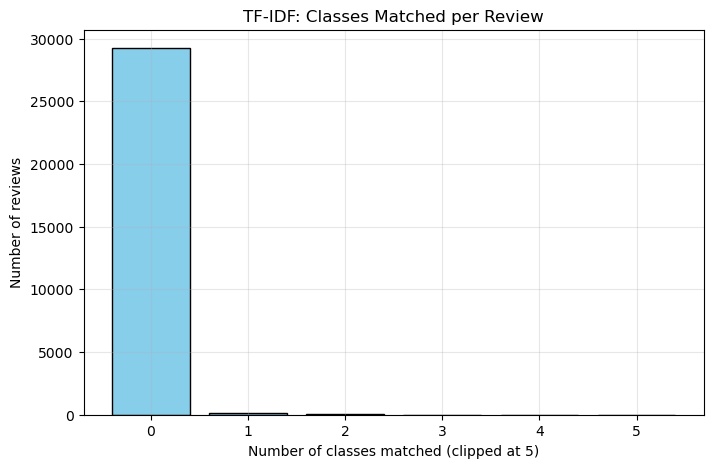

0 classes: 29250 reviews
1 classes: 152 reviews
2 classes: 81 reviews
3 classes: 4 reviews
4 classes: 0 reviews
5 classes: 0 reviews


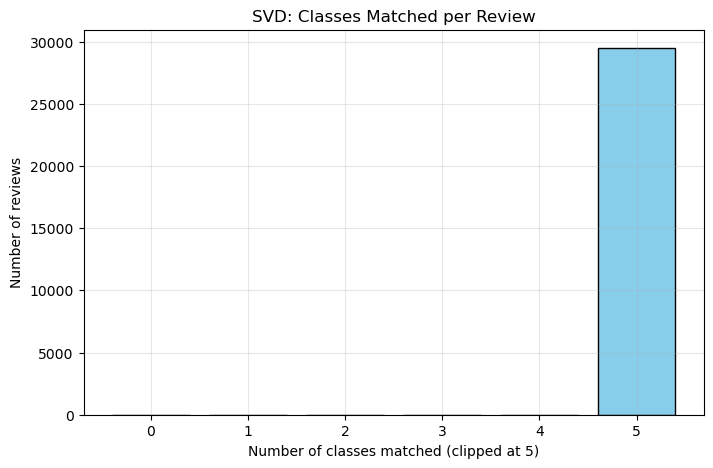

0 classes: 1 reviews
1 classes: 2 reviews
2 classes: 0 reviews
3 classes: 1 reviews
4 classes: 0 reviews
5 classes: 29483 reviews


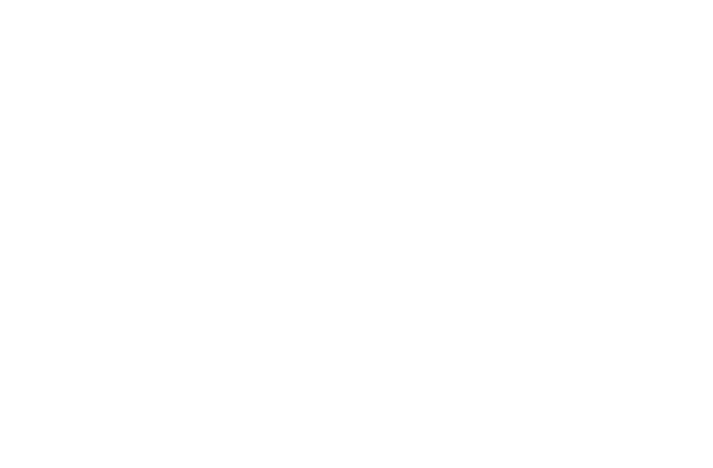

0 classes: 27933 reviews
1 classes: 1164 reviews
2 classes: 220 reviews
3 classes: 88 reviews
4 classes: 39 reviews
5 classes: 43 reviews


In [8]:
# How many classes per review
def plot_classes_per_review(similarity_matrix, min_conf=0.6, clip_max=5, title=None):
    if hasattr(similarity_matrix, "toarray"):
        sim_dense = similarity_matrix.toarray()
    else:
        sim_dense = similarity_matrix

    num_classes_per_review = (sim_dense >= min_conf).sum(axis=1)
    num_classes_per_review_clipped = np.clip(num_classes_per_review, 0, clip_max)

    counter = Counter(num_classes_per_review_clipped)
    counts = [counter.get(i, 0) for i in range(clip_max+1)]

    plt.figure(figsize=(8,5))
    plt.bar(range(clip_max+1), counts, color='skyblue', edgecolor='black')
    plt.xticks(range(clip_max+1))
    plt.title(title or f"Number of Classes per Review (conf >= {min_conf})")
    plt.xlabel(f"Number of classes matched (clipped at {clip_max})")
    plt.ylabel("Number of reviews")
    plt.grid(alpha=0.3)
    plt.show()

    for i, c in enumerate(counts):
        print(f"{i} classes: {c} reviews")

    return num_classes_per_review_clipped

# TF-IDF
num_classes_tfidf = plot_classes_per_review(
    similarity_matrix_tfidf, 
    min_conf=0.6, 
    clip_max=5, 
    title="TF-IDF: Classes Matched per Review"
)

# SVD
num_classes_svd = plot_classes_per_review(
    similarity_matrix_svd, 
    min_conf=0.6, 
    clip_max=5, 
    title="SVD: Classes Matched per Review"
)

# BERT
num_classes_bert = plot_classes_per_review(
    similarity_matrix_bert, 
    min_conf=0.6, 
    clip_max=5, 
    title="BERT: Classes Matched per Review"
)


# e. Embedding Table

In [9]:
# Class Embedding Table

CLASS_EMB_PATH = REPRESENTATION_PATH / "class_embeddings"
CLASS_EMB_PATH.mkdir(exist_ok=True)

class_vectorizer = TfidfVectorizer(max_features=5000)
class_vectorizer.fit(keyword_docs)
class_tfidf = class_vectorizer.transform(keyword_docs)



SVD_DIM_CLASS = 128
svd_class = TruncatedSVD(n_components=SVD_DIM_CLASS, n_iter=10, random_state=42)
class_dense = svd_class.fit_transform(class_tfidf)

def l2_normalize_rows(mat):
    norms = np.linalg.norm(mat, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    return mat / norms

class_dense = l2_normalize_rows(class_dense)

np.save(CLASS_EMB_PATH / "class_embeddings.npy", class_dense)
with open(CLASS_EMB_PATH / "class_names.pkl", "wb") as f:
    pickle.dump(class_names, f)
with open(CLASS_EMB_PATH / "class_vectorizer.pkl", "wb") as f:
    pickle.dump(class_vectorizer, f)
with open(CLASS_EMB_PATH / "svd_class_model.pkl", "wb") as f:
    pickle.dump(svd_class, f)

print(f"[DONE] Saved class embeddings for {len(class_names)} classes at {CLASS_EMB_PATH}")


[DONE] Saved class embeddings for 531 classes at representations/class_embeddings


# f. Silver Labels

## I. a, b & c

In [12]:
TOP_K = 3
CONF_THRESH = 0.6

tfidf = TfidfVectorizer(max_features=5000)
tfidf.fit(train_texts)

train_tfidf = tfidf.transform(train_texts).toarray()
class_tfidf = tfidf.transform(keyword_docs).toarray()

sim_matrix = cosine_similarity(train_tfidf, class_tfidf)

silver_labels_tfidf = []
for i, sims in enumerate(sim_matrix):
    top_idx = sims.argsort()[::-1][:TOP_K]
    labels = [(class_names[j], float(sims[j])) for j in top_idx if sims[j] >= CONF_THRESH]
    silver_labels_tfidf.append((train_ids[i], labels))

with open(SILVER_PATH / "silver_labels_tfidf.pkl", "wb") as f:
    pickle.dump(silver_labels_tfidf, f)


In [13]:
TOP_K = 3
CONF_THRESH = 0.6

svd = TruncatedSVD(n_components=128, random_state=42)

train_svd = svd.fit_transform(train_tfidf)
class_svd = svd.transform(class_tfidf)

sim_matrix = cosine_similarity(train_svd, class_svd)

silver_labels_svd = []
for i, sims in enumerate(sim_matrix):
    top_idx = sims.argsort()[::-1][:TOP_K]
    labels = [(class_names[j], float(sims[j])) for j in top_idx if sims[j] >= CONF_THRESH]
    silver_labels_svd.append((train_ids[i], labels))

with open(SILVER_PATH / "silver_labels_svd.pkl", "wb") as f:
    pickle.dump(silver_labels_svd, f)

In [14]:
TOP_K = 3
CONF_THRESH = 0.6

model_name = "sentence-transformers/all-mpnet-base-v2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to(device)

def embed(texts, batch_size=64):
    out = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tokenizer(batch, padding=True, truncation=True, return_tensors="pt").to(device)
        with torch.no_grad():
            h = model(**enc).last_hidden_state.mean(dim=1)
        out.append(h.cpu().numpy())
    return np.vstack(out)

train_bert = embed(train_texts)
class_bert = embed(keyword_docs)

sim_matrix = cosine_similarity(train_bert, class_bert)

silver_labels_bert = []
for i, sims in enumerate(sim_matrix):
    top_idx = sims.argsort()[::-1][:TOP_K]
    labels = [(class_names[j], float(sims[j])) for j in top_idx if sims[j] >= CONF_THRESH]
    silver_labels_bert.append((train_ids[i], labels))

with open(SILVER_PATH / "silver_labels_bert.pkl", "wb") as f:
    pickle.dump(silver_labels_bert, f)


## II. Hybrid Labels